In [88]:
import pandas as pd
import plotly.graph_objects as go

In [89]:
zip_df = pd.read_csv(r"C:\Users\frahman\Downloads\top15_od_pairs_3.csv")
county_df = pd.read_csv(r"C:\Users\frahman\Downloads\top15_od_pairs_counties_3.csv")

In [90]:
def make_sankey(df, title):
    bottleneck_title = "2025 Bottleneck Rank 3: I-495 CCW @ MD-97/GEORGIA AVE/EXIT 31"

    plot_df = df.copy()

    # Clean fields
    plot_df["origin"] = plot_df["origin"].astype(str).str.strip()
    plot_df["destination"] = plot_df["destination"].astype(str).str.strip()
    plot_df["volume"] = pd.to_numeric(plot_df["volume"], errors="coerce")

    plot_df = plot_df.dropna(subset=["origin", "destination", "volume"])
    plot_df = plot_df[plot_df["volume"] > 0]
    plot_df = plot_df[plot_df["origin"] != plot_df["destination"]]

    # Rank OD pairs by volume
    plot_df = plot_df.sort_values("volume", ascending=False).reset_index(drop=True)
    plot_df["od_rank"] = plot_df.index + 1
    plot_df["share"] = plot_df["volume"] / plot_df["volume"].sum()
    plot_df["od_pair"] = plot_df["origin"] + " → " + plot_df["destination"]

    origin_labels = plot_df["origin"].drop_duplicates().tolist()
    destination_labels = plot_df["destination"].drop_duplicates().tolist()
    labels = origin_labels + destination_labels

    origin_to_index = {origin: i for i, origin in enumerate(origin_labels)}
    dest_to_index = {
        dest: i + len(origin_labels)
        for i, dest in enumerate(destination_labels)
    }

    sources = plot_df["origin"].map(origin_to_index)
    targets = plot_df["destination"].map(dest_to_index)
    values = plot_df["volume"]

    customdata = plot_df[[
        "od_rank",
        "origin",
        "destination",
        "volume",
        "share"
    ]].values

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        domain=dict(x=[0.04, 0.94], y=[0.26, 0.90]),
        node=dict(
            pad=34,
            thickness=24,
            line=dict(color="black", width=0.5),
            label=labels,
            hovertemplate=(
                "<b>%{label}</b><br>"
                "Total shown OD volume: %{value:,.0f}"
                "<extra></extra>"
            )
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            customdata=customdata,
            hovertemplate=(
                "<b>OD Pair Rank %{customdata[0]}</b><br>"
                "%{customdata[1]} → %{customdata[2]}<br>"
                "Volume: %{customdata[3]:,.0f}<br>"
                "Share of shown top-15 volume: %{customdata[4]:.1%}"
                "<extra></extra>"
            )
        )
    )])

    total_volume = plot_df["volume"].sum()
    top_pair = plot_df.iloc[0]
    top_5_share = plot_df.head(5)["volume"].sum() / total_volume

    dominant_origin = (
        plot_df.groupby("origin")["volume"]
        .sum()
        .sort_values(ascending=False)
    )
    dominant_destination = (
        plot_df.groupby("destination")["volume"]
        .sum()
        .sort_values(ascending=False)
    )

    top_origin = dominant_origin.index[0]
    top_origin_share = dominant_origin.iloc[0] / total_volume

    top_destination = dominant_destination.index[0]
    top_destination_share = dominant_destination.iloc[0] / total_volume

    finding_text = (
        f"<b>Key finding:</b> The shown top-15 OD flows are mainly driven by "
        f"<b>{top_origin}</b> as the leading origin ({top_origin_share:.1%}) and "
        f"<b>{top_destination}</b> as the leading destination ({top_destination_share:.1%}).<br>"
        f"Largest OD pair: <b>{top_pair['origin']} → {top_pair['destination']}</b> "
        f"({top_pair['volume']:,.0f}, {top_pair['share']:.1%}). "
        f"Top 5 OD pairs account for <b>{top_5_share:.1%}</b> of shown volume."
    )

    # Ranked table below Sankey
    table_df = plot_df.head(15).copy()
    table_df["volume_text"] = table_df["volume"].map(lambda x: f"{x:,.0f}")
    table_df["share_text"] = table_df["share"].map(lambda x: f"{x:.1%}")

    fig.add_trace(
        go.Table(
            domain=dict(x=[0.04, 0.94], y=[0.0, 0.22]),
            header=dict(
                values=[
                    "<b>Rank</b>",
                    "<b>Origin</b>",
                    "<b>Destination</b>",
                    "<b>Volume</b>",
                    "<b>Share</b>"
                ],
                fill_color="#F1F3F5",
                align=["center", "left", "left", "right", "right"],
                font=dict(size=14, color="#24313A"),
                height=26
            ),
            cells=dict(
                values=[
                    table_df["od_rank"],
                    table_df["origin"],
                    table_df["destination"],
                    table_df["volume_text"],
                    table_df["share_text"]
                ],
                fill_color="white",
                align=["center", "left", "left", "right", "right"],
                font=dict(size=11, color="#24313A"),
                height=24
            )
        )
    )

    fig.update_layout(
        title=dict(
            text=(
                f"<b>{title}</b><br>"
                f"<span style='font-size:22px'><b>{bottleneck_title}</b></span>"
            ),
            x=0.02,
            y=0.98,
            xanchor="left",
            yanchor="top"
        ),
        font=dict(size=14, family="Arial", color="#050608"),
        width=1250,
        height=1040,
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=60, r=110, t=230, b=30),
        annotations=[
            dict(
                text=finding_text,
                x=0.04,
                y=1.055,
                xref="paper",
                yref="paper",
                showarrow=False,
                align="left",
                font=dict(size=14, color="#24313A"),
                bgcolor="rgba(245,245,245,0.98)",
                bordercolor="#D8DEE3",
                borderwidth=1,
                borderpad=10
            ),
            dict(
                text="<b>Origins</b>",
                x=0.04,
                y=0.965,
                xref="paper",
                yref="paper",
                showarrow=False,
                align="left",
                font=dict(size=14, color="#4A555C")
            ),
            dict(
                text="<b>Destinations</b>",
                x=0.94,
                y=0.965,
                xref="paper",
                yref="paper",
                showarrow=False,
                align="right",
                font=dict(size=14, color="#4A555C")
            )
        ]
    )

    return fig

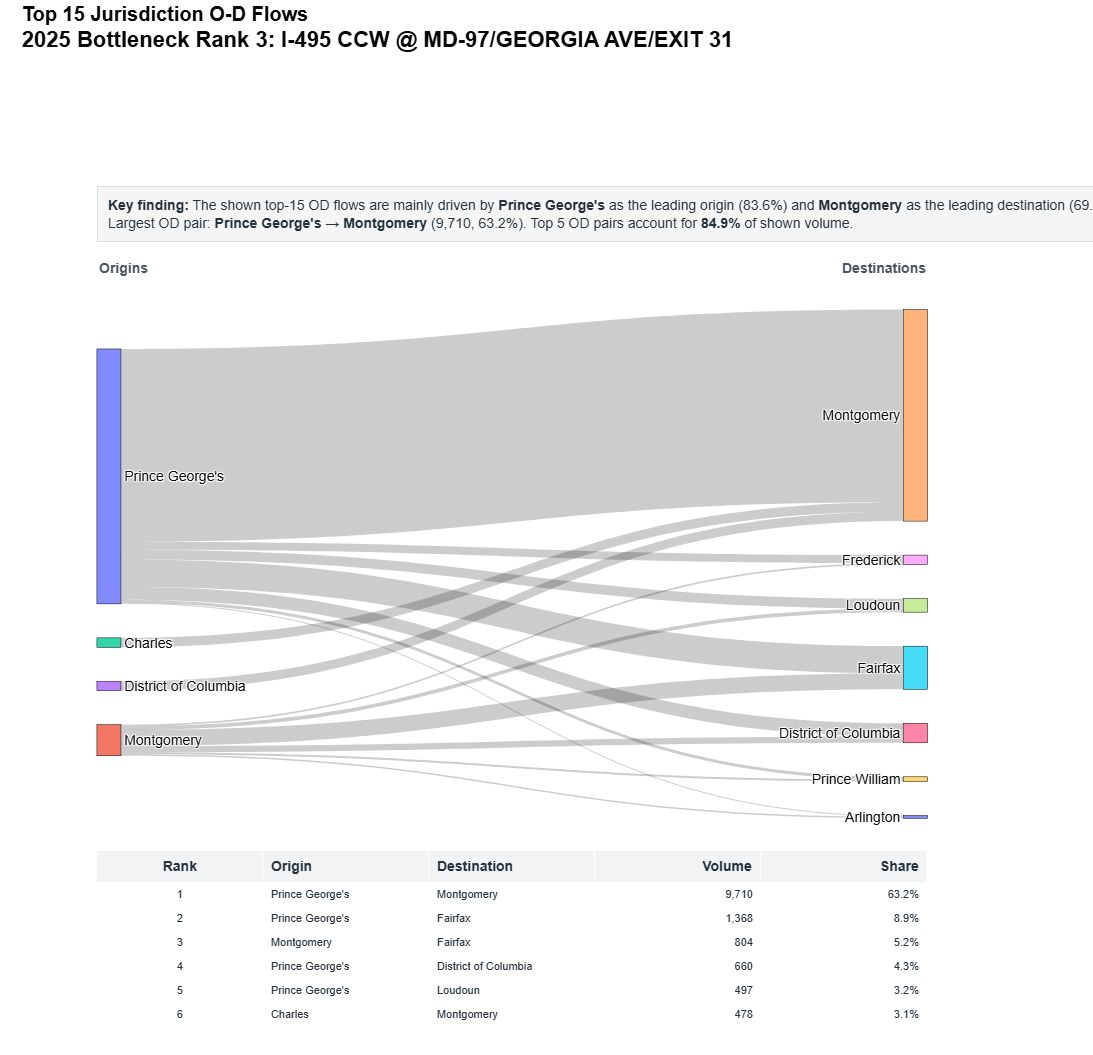

In [91]:
county_sankey = make_sankey(county_df, "Top 15 Jurisdiction O-D Flows")
county_sankey

In [92]:
county_sankey.write_html("county_od_sankey.html")

In [93]:
zip_sankey = make_sankey(zip_df, "Top 15 ZIP Code O-D Flows")
zip_sankey.write_html("zip_od_sankey.html")

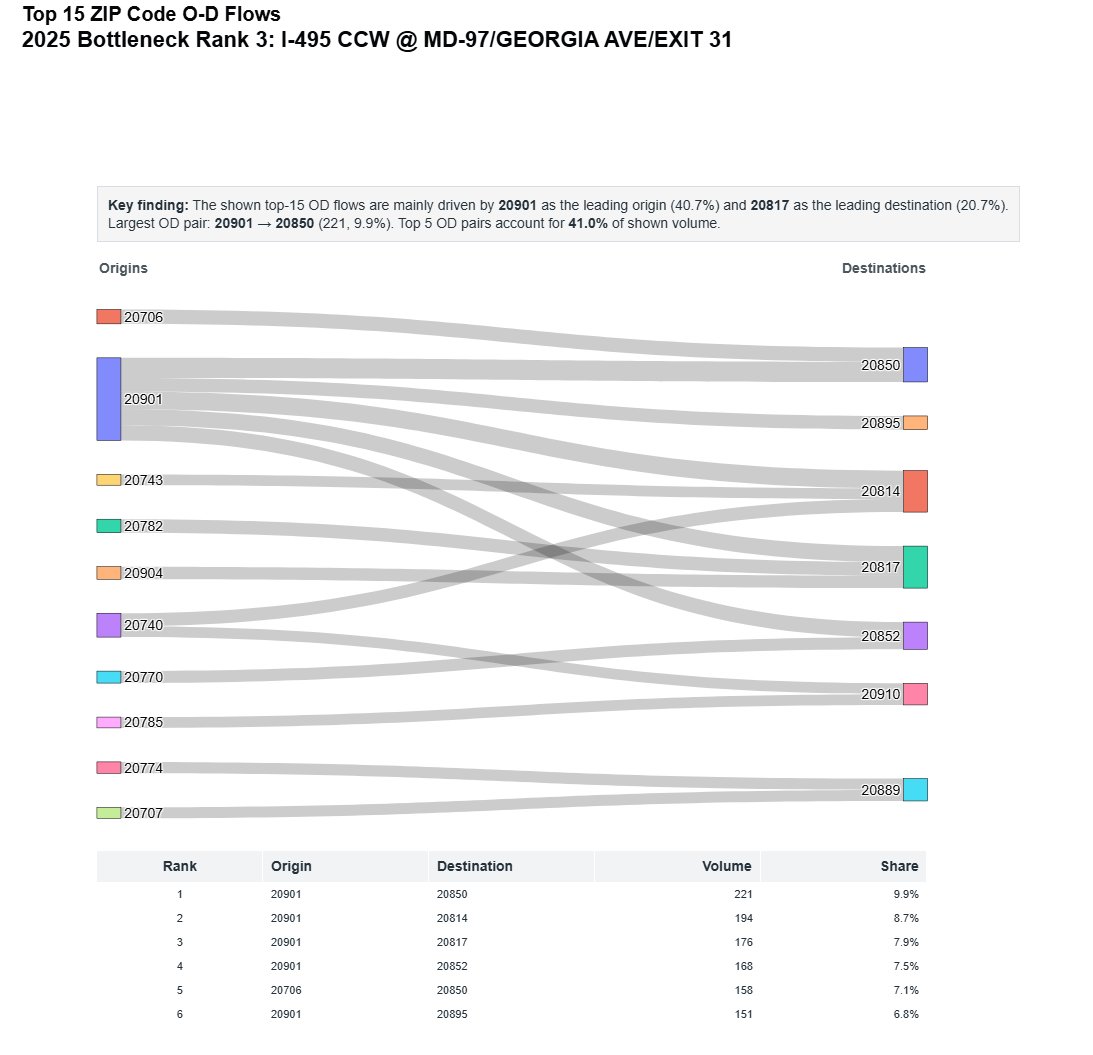

In [94]:
zip_sankey